# Day 3 — RNNs & LSTMs for Sequential ECG Data

## ECG Heartbeat Classification

This notebook explores Recurrent Neural Networks (RNNs) and Long Short-Term Memory (LSTM) networks for classifying ECG heartbeat signals.

The main goal is to understand why sequential data requires order-aware architectures and to evaluate whether LSTM can improve heartbeat classification compared with a plain RNN baseline.

## Overview

ECG signals are sequential time-series data, where each value represents the electrical activity of the heart at a specific point in time.

Unlike traditional tabular data, the order of signal measurements is important. A heartbeat pattern cannot be fully understood by treating its measurements as independent features.

In this notebook, we will:

- Explore and visualize the ECG dataset.
- Prepare ECG signals for sequential modeling.
- Build a baseline Simple RNN model.
- Build an LSTM model.
- Compare the performance of RNN and LSTM.
- Analyze training behavior and classification performance.
- Explain why order-awareness is important for ECG heartbeat classification.

## Dataset

### ECG Heartbeat Categorization Dataset

The dataset contains segmented and preprocessed ECG heartbeat signals.

For this notebook, we will focus on the **MIT-BIH Arrhythmia** dataset, which contains five heartbeat categories:

| Label | Category | Description |
|------:|----------|-------------|
| 0 | N | Normal |
| 1 | S | Supraventricular |
| 2 | V | Ventricular |
| 3 | F | Fusion |
| 4 | Q | Unknown / Unclassifiable |

Each heartbeat is represented as a sequence of **187 signal measurements**.

Therefore, each sample can be treated as a sequence of:

- **187 time steps**
- **1 feature per time step**

The input shape for the sequential models will therefore be:

`(187, 1)`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
train_df = pd.read_csv("mitbih_train.csv", header=None)
test_df = pd.read_csv("mitbih_test.csv", header=None)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


## Verifying the Dataset Structure

The dataset contains 188 columns for each heartbeat sample.

The first 187 columns represent the ECG signal measurements across time, while the final column contains the heartbeat class label.

In [3]:
print("Number of columns:", train_df.shape[1])

print("\nFirst 5 signal values:")
print(train_df.iloc[0, :5].values)

print("\nLast 5 values:")
print(train_df.iloc[0, -5:].values)

Number of columns: 188

First 5 signal values:
[0.97794116 0.92647058 0.68137252 0.24509804 0.15441176]

Last 5 values:
[0. 0. 0. 0. 0.]


In [4]:
y_train_raw = train_df.iloc[:, -1]
y_test_raw = test_df.iloc[:, -1]

print("Unique labels in training set:")
print(sorted(y_train_raw.dropna().unique()))

print("\nTraining class distribution:")
print(y_train_raw.value_counts(dropna=False).sort_index())

print("\nTest class distribution:")
print(y_test_raw.value_counts(dropna=False).sort_index())

Unique labels in training set:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]

Training class distribution:
187
0.0    72471
1.0     2223
2.0     5788
3.0      641
4.0     6431
Name: count, dtype: int64

Test class distribution:
187
0.0    18118
1.0      556
2.0     1448
3.0      162
4.0     1608
Name: count, dtype: int64


## Data Quality Check

Before preparing the ECG signals for sequential modeling, we check for missing values and duplicate samples in both the training and test sets.

Missing values in ECG measurements need to be handled before training because neural networks cannot process `NaN` values correctly.

In [5]:
print("Missing values in training set:", train_df.isnull().sum().sum())
print("Missing values in test set:", test_df.isnull().sum().sum())

print("Duplicate rows in training set:", train_df.duplicated().sum())
print("Duplicate rows in test set:", test_df.duplicated().sum())

Missing values in training set: 0
Missing values in test set: 0
Duplicate rows in training set: 0
Duplicate rows in test set: 0


In [6]:
X_train = train_df.iloc[:, :-1].copy()
y_train = train_df.iloc[:, -1].copy()

X_test = test_df.iloc[:, :-1].copy()
y_test = test_df.iloc[:, -1].copy()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (87554, 187)
y_train shape: (87554,)
X_test shape: (21892, 187)
y_test shape: (21892,)


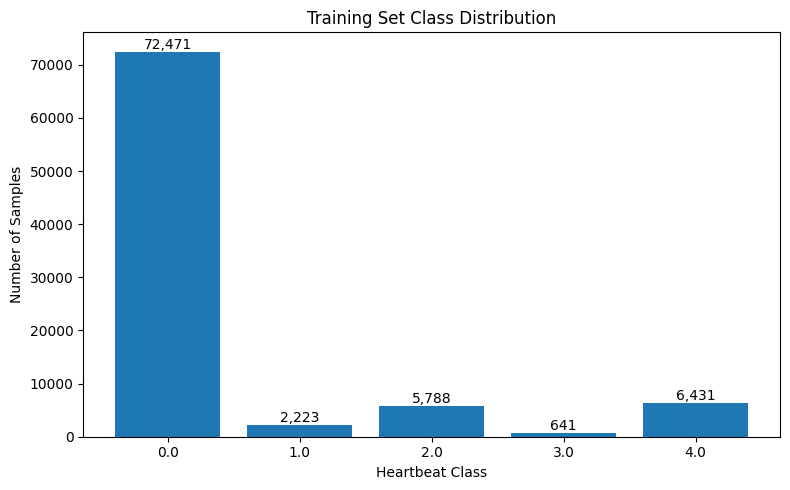

In [7]:
plt.figure(figsize=(8, 5))

class_counts = y_train.value_counts().sort_index()

bars = plt.bar(
    class_counts.index.astype(str),
    class_counts.values
)

plt.title("Training Set Class Distribution")
plt.xlabel("Heartbeat Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

for bar, count in zip(bars, class_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [8]:
class_counts = y_train.value_counts().sort_index()
class_percentages = y_train.value_counts(normalize=True).sort_index() * 100

class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages.round(2)
})

class_distribution

,Count,Percentage
187,,
0.0,72471,82.77
1.0,2223,2.54
2.0,5788,6.61
3.0,641,0.73
4.0,6431,7.35


## Comparing Multiple ECG Signals per Class

A single heartbeat may not represent the full variability within a class.

Therefore, we visualize multiple ECG signals from each heartbeat category to observe common patterns and variations within the classes.

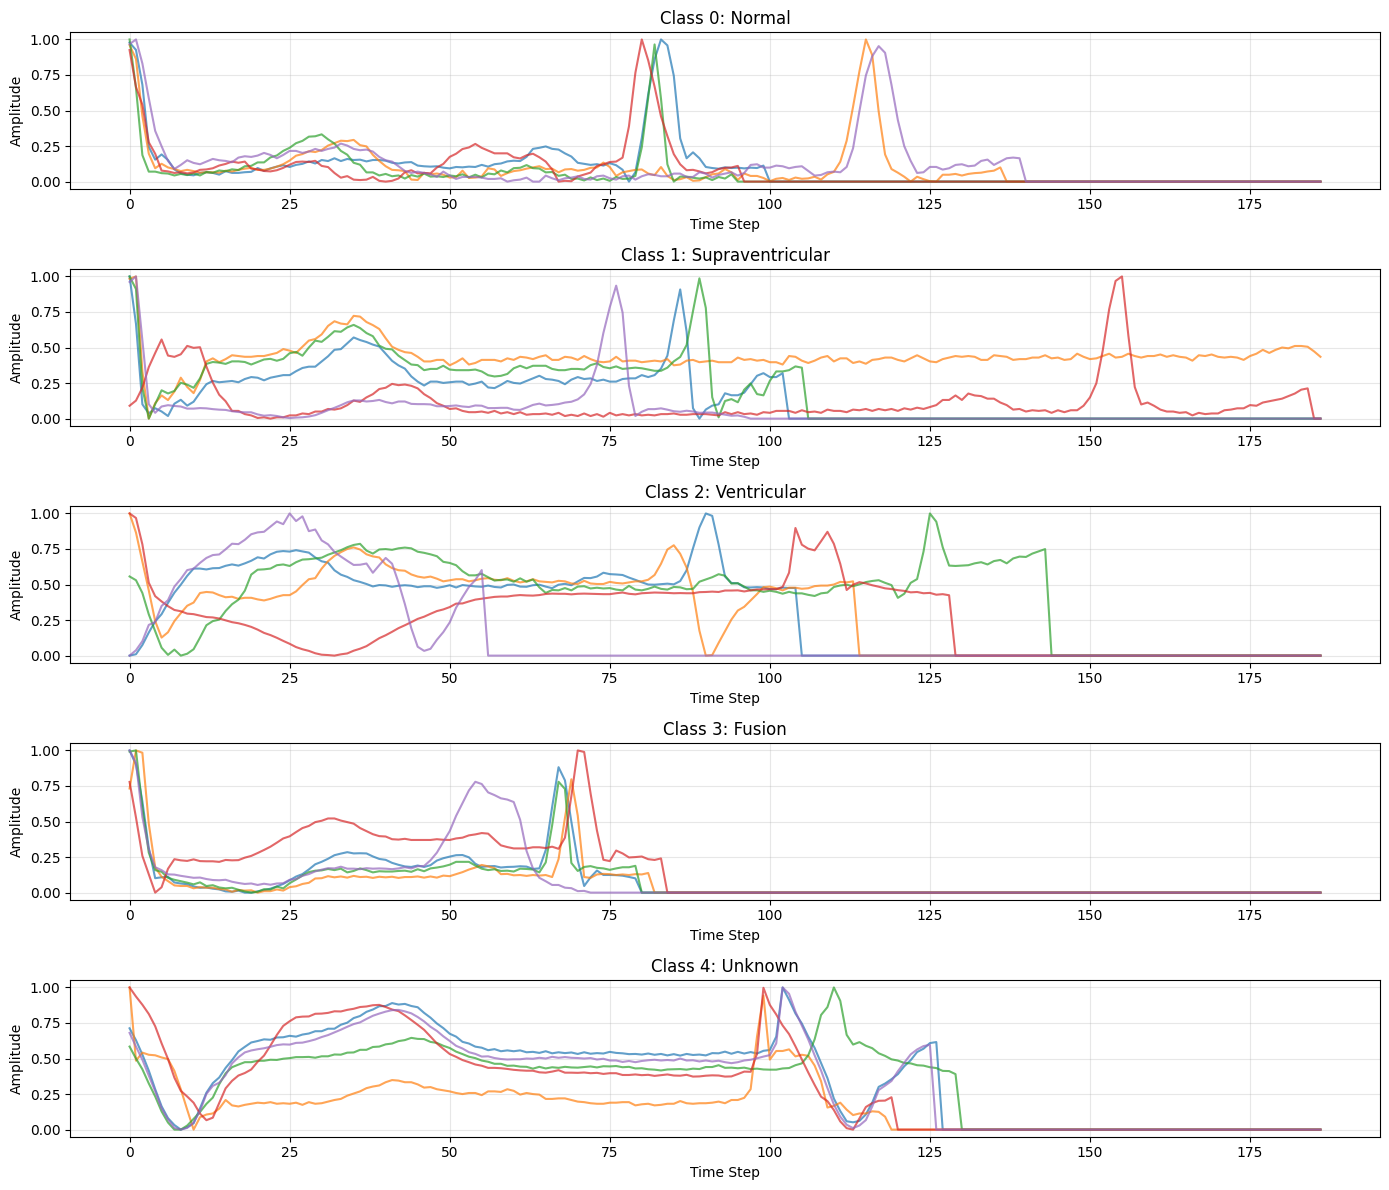

In [10]:
class_names = {
    0: "Normal",
    1: "Supraventricular",
    2: "Ventricular",
    3: "Fusion",
    4: "Unknown"
}

class_names

fig, axes = plt.subplots(5, 1, figsize=(14, 12))

for ax, class_id in zip(axes, sorted(class_names.keys())):
    class_indices = np.where(y_train.values == class_id)[0][:5]

    for index in class_indices:
        ax.plot(X_train.iloc[index].values, alpha=0.7)

    ax.set_title(f"Class {class_id}: {class_names[class_id]}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Amplitude")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Preparing Data for Sequential Modeling

RNNs and LSTMs expect sequential input in the following format:

`(samples, time steps, features)`

In our ECG dataset:

- Each sample represents one heartbeat.
- Each heartbeat contains 187 time steps.
- Each time step contains one ECG amplitude value.

Therefore, the input data will be reshaped from:

`(samples, 187)`

to:

`(samples, 187, 1)`

This allows the model to process each ECG measurement as a time step while preserving the temporal order of the signal.

In [11]:
# Convert DataFrames to NumPy arrays
X_train = X_train.values.astype("float32")
X_test = X_test.values.astype("float32")

# Convert labels to integer type
y_train = y_train.values.astype("int32")
y_test = y_test.values.astype("int32")

# Reshape ECG signals for RNN/LSTM
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (87554, 187, 1)
X_test shape: (21892, 187, 1)
y_train shape: (87554,)
y_test shape: (21892,)


## Creating a Validation Set

The original training data is divided into training and validation sets.

The validation set is used during model development to monitor how well the model generalizes to unseen data.

A stratified split is used to preserve the original class distribution in both subsets, which is especially important because the dataset is highly imbalanced.

In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (70043, 187, 1) (70043,)
Validation set: (17511, 187, 1) (17511,)
Test set: (21892, 187, 1) (21892,)


## Building a Simple RNN Baseline

A Simple Recurrent Neural Network (RNN) is used as a baseline model for ECG heartbeat classification.

The RNN processes the ECG signal one time step at a time and maintains a hidden state that carries information from previous time steps.

This baseline will later be compared with the LSTM model to evaluate whether gated memory improves sequential learning for ECG signals.

In [13]:
rnn_model = Sequential([
    SimpleRNN(64, input_shape=(187, 1)),
    Dense(5, activation="softmax")
])

rnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,549 (17.77 KB)

 Trainable params: 4,549 (17.77 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
rnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.8278 - loss: 0.6523 - val_accuracy: 0.8279 - val_loss: 0.6483
Epoch 2/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 28s 50ms/step - accuracy: 0.8277 - loss: 0.6501 - val_accuracy: 0.8277 - val_loss: 0.6593
Epoch 3/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.8200 - loss: 0.6696 - val_accuracy: 0.8278 - val_loss: 0.6510
Epoch 4/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 43s 53ms/step - accuracy: 0.8281 - loss: 0.6507 - val_accuracy: 0.8282 - val_loss: 0.6516
Epoch 5/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - accuracy: 0.8278 - loss: 0.6539 - val_accuracy: 0.8277 - val_loss: 0.6583
Epoch 6/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.8277 - loss: 0.6542 - val_accuracy: 0.8277 - val_loss: 0.6527


In [17]:
# Predict class probabilities
y_pred_proba = rnn_model.predict(X_test, verbose=0)

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_proba, axis=1)

# Calculate metrics
rnn_accuracy = accuracy_score(y_test, y_pred)
rnn_precision = precision_score(
    y_test, y_pred, average="macro", zero_division=0
)
rnn_recall = recall_score(
    y_test, y_pred, average="macro", zero_division=0
)
rnn_f1 = f1_score(
    y_test, y_pred, average="macro", zero_division=0
)

print(f"Accuracy:  {rnn_accuracy:.4f}")
print(f"Precision: {rnn_precision:.4f}")
print(f"Recall:    {rnn_recall:.4f}")
print(f"Macro F1:  {rnn_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[class_names[i] for i in range(5)],
        zero_division=0
    ))

Accuracy:  0.8280
Precision: 0.2900
Recall:    0.2018
Macro F1:  0.1849

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.83      1.00      0.91     18118
Supraventricular       0.07      0.00      0.00       556
     Ventricular       0.55      0.01      0.01      1448
          Fusion       0.00      0.00      0.00       162
         Unknown       0.00      0.00      0.00      1608

        accuracy                           0.83     21892
       macro avg       0.29      0.20      0.18     21892
    weighted avg       0.72      0.83      0.75     21892



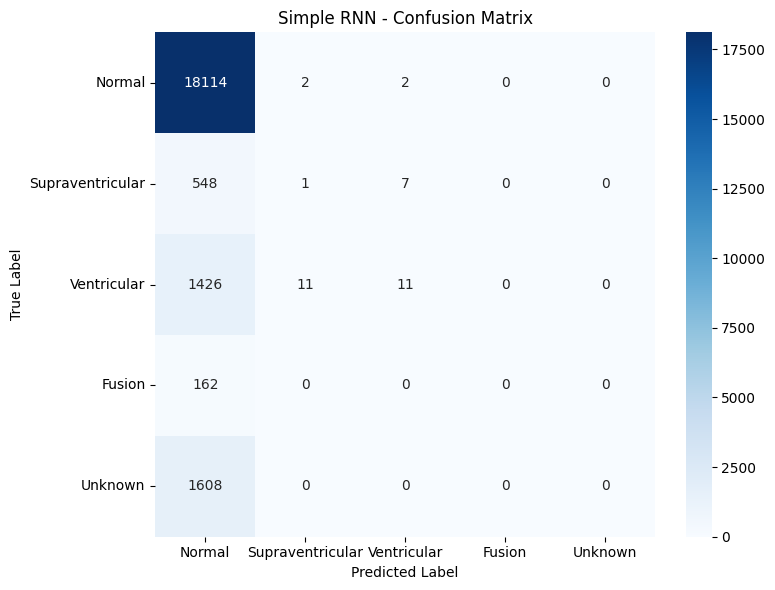

In [20]:
import seaborn as sns
cm_rnn = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_rnn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Normal",
        "Supraventricular",
        "Ventricular",
        "Fusion",
        "Unknown"
    ],
    yticklabels=[
        "Normal",
        "Supraventricular",
        "Ventricular",
        "Fusion",
        "Unknown"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Simple RNN - Confusion Matrix")

plt.tight_layout()
plt.show()

## Building an LSTM Model

Long Short-Term Memory (LSTM) is a specialized type of RNN designed to learn dependencies across longer sequences.

Unlike a plain RNN, an LSTM uses gated memory mechanisms to control what information should be retained, forgotten, and passed to the next time step.

For ECG classification, this allows the model to capture important temporal patterns across the 187 measurements of each heartbeat.

In [21]:
lstm_model = Sequential([
    LSTM(64, input_shape=(187, 1)),
    Dense(5, activation="softmax")
])

lstm_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,221 (67.27 KB)

 Trainable params: 17,221 (67.27 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)




Epoch 1/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 139s 247ms/step - accuracy: 0.8276 - loss: 0.6783 - val_accuracy: 0.8281 - val_loss: 0.6527
Epoch 2/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 126s 230ms/step - accuracy: 0.8281 - loss: 0.6476 - val_accuracy: 0.8283 - val_loss: 0.6401
Epoch 3/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 143s 231ms/step - accuracy: 0.8283 - loss: 0.6457 - val_accuracy: 0.8281 - val_loss: 0.6467
Epoch 4/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 136s 249ms/step - accuracy: 0.8282 - loss: 0.6407 - val_accuracy: 0.8279 - val_loss: 0.6190
Epoch 5/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 128s 233ms/step - accuracy: 0.8278 - loss: 0.6488 - val_accuracy: 0.8279 - val_loss: 0.6442
Epoch 6/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 128s 234ms/step - accuracy: 0.8281 - loss: 0.6319 - val_accuracy: 0.8279 - val_loss: 0.6013
Epoch 7/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 131s 239ms/step - accuracy: 0.8282 - loss: 0.5718 - val_accuracy: 0.8153 - val_loss: 0.5998
Epoch 8/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 131s 238ms/step - accuracy: 0.8310 -

In [23]:
# Generate LSTM predictions
y_pred_proba_lstm = lstm_model.predict(X_test, verbose=0)

# Convert probabilities to predicted class labels
y_pred_lstm = np.argmax(y_pred_proba_lstm, axis=1)

# Calculate metrics
lstm_accuracy = accuracy_score(y_test, y_pred_lstm)

lstm_precision = precision_score(
    y_test,
    y_pred_lstm,
    average="macro",
    zero_division=0
)

lstm_recall = recall_score(
    y_test,
    y_pred_lstm,
    average="macro",
    zero_division=0
)

lstm_f1 = f1_score(
    y_test,
    y_pred_lstm,
    average="macro",
    zero_division=0
)

print(f"Accuracy:  {lstm_accuracy:.4f}")
print(f"Precision: {lstm_precision:.4f}")
print(f"Recall:    {lstm_recall:.4f}")
print(f"Macro F1:  {lstm_f1:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_lstm,
        target_names=[
            "Normal",
            "Supraventricular",
            "Ventricular",
            "Fusion",
            "Unknown"
        ],
        zero_division=0
    )
)

Accuracy:  0.9479
Precision: 0.8041
Recall:    0.6381
Macro F1:  0.6847

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.96      0.99      0.97     18118
Supraventricular       0.84      0.40      0.54       556
     Ventricular       0.83      0.80      0.81      1448
          Fusion       0.43      0.10      0.16       162
         Unknown       0.96      0.90      0.93      1608

        accuracy                           0.95     21892
       macro avg       0.80      0.64      0.68     21892
    weighted avg       0.94      0.95      0.94     21892



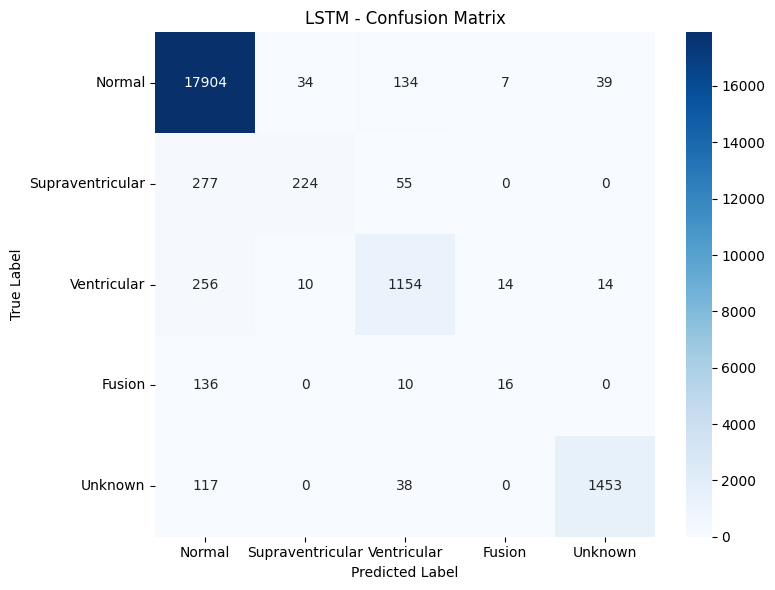

In [24]:
cm_lstm = confusion_matrix(
    y_test,
    y_pred_lstm
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_lstm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Normal",
        "Supraventricular",
        "Ventricular",
        "Fusion",
        "Unknown"
    ],
    yticklabels=[
        "Normal",
        "Supraventricular",
        "Ventricular",
        "Fusion",
        "Unknown"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("LSTM - Confusion Matrix")

plt.tight_layout()
plt.show()

## RNN vs LSTM Performance Comparison

The Simple RNN and LSTM models are compared using the same ECG dataset, data split, and evaluation metrics.

The LSTM significantly outperforms the Simple RNN, especially in macro-averaged metrics. This indicates that the LSTM is substantially better at recognizing minority heartbeat classes rather than relying mainly on the majority Normal class.

In [25]:
comparison_df = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM"],
    "Accuracy": [rnn_accuracy, lstm_accuracy],
    "Macro Precision": [rnn_precision, lstm_precision],
    "Macro Recall": [rnn_recall, lstm_recall],
    "Macro F1": [rnn_f1, lstm_f1]
})

comparison_df.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Simple RNN,0.8280,0.2900,0.2018,0.1849
1,LSTM,0.9479,0.8041,0.6381,0.6847


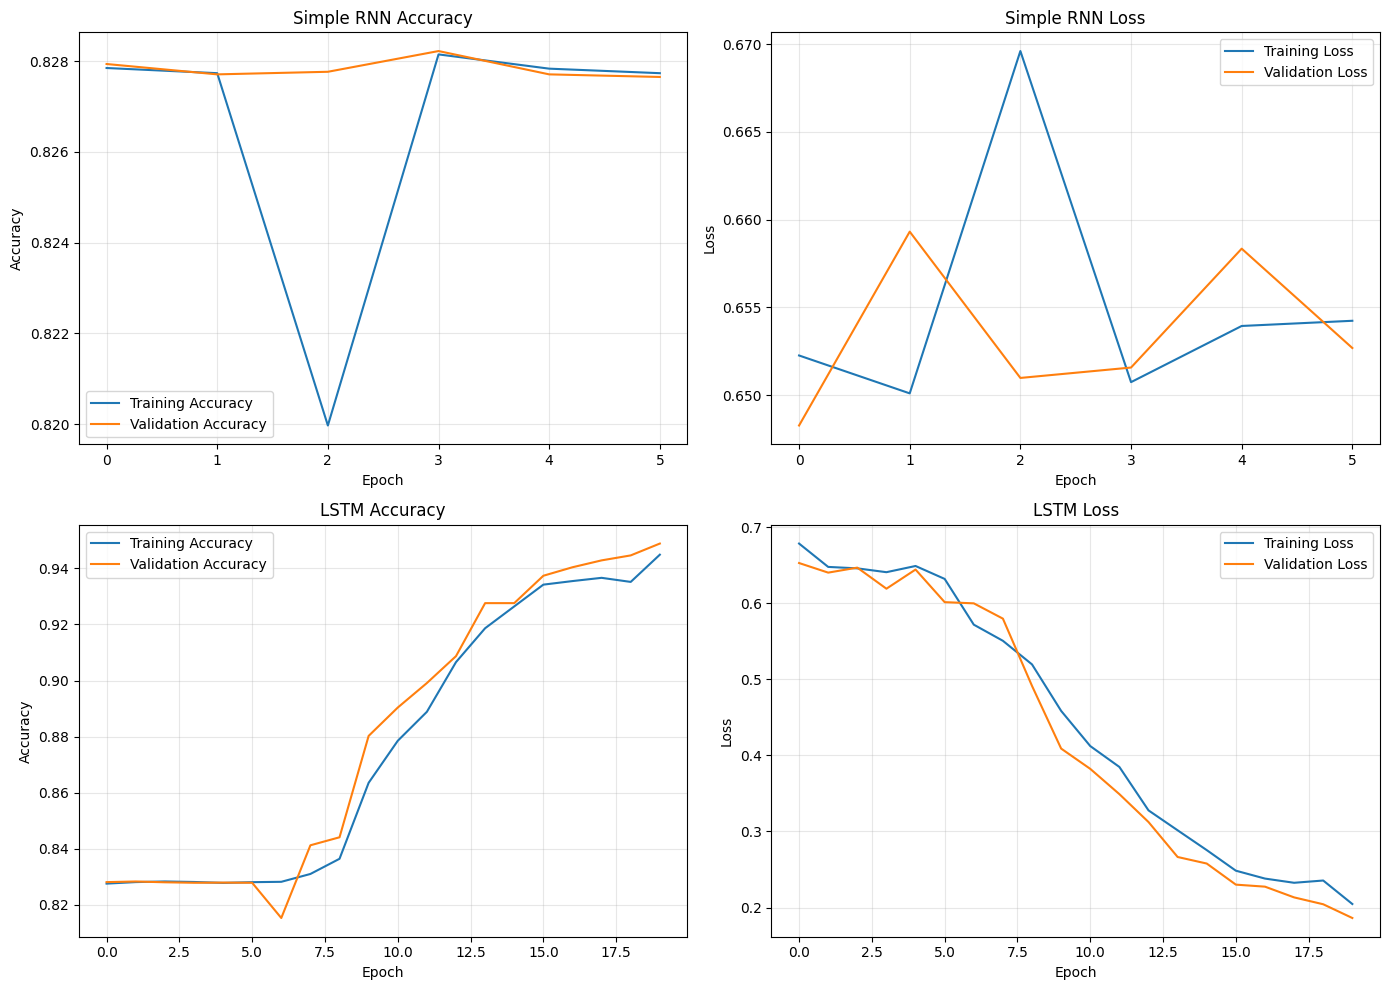

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# =========================
# RNN Accuracy
# =========================
axes[0, 0].plot(
    rnn_history.history["accuracy"],
    label="Training Accuracy"
)

axes[0, 0].plot(
    rnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

axes[0, 0].set_title("Simple RNN Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)


# =========================
# RNN Loss
# =========================
axes[0, 1].plot(
    rnn_history.history["loss"],
    label="Training Loss"
)

axes[0, 1].plot(
    rnn_history.history["val_loss"],
    label="Validation Loss"
)

axes[0, 1].set_title("Simple RNN Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)


# =========================
# LSTM Accuracy
# =========================
axes[1, 0].plot(
    lstm_history.history["accuracy"],
    label="Training Accuracy"
)

axes[1, 0].plot(
    lstm_history.history["val_accuracy"],
    label="Validation Accuracy"
)

axes[1, 0].set_title("LSTM Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)


# =========================
# LSTM Loss
# =========================
axes[1, 1].plot(
    lstm_history.history["loss"],
    label="Training Loss"
)

axes[1, 1].plot(
    lstm_history.history["val_loss"],
    label="Validation Loss"
)

axes[1, 1].set_title("LSTM Loss")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

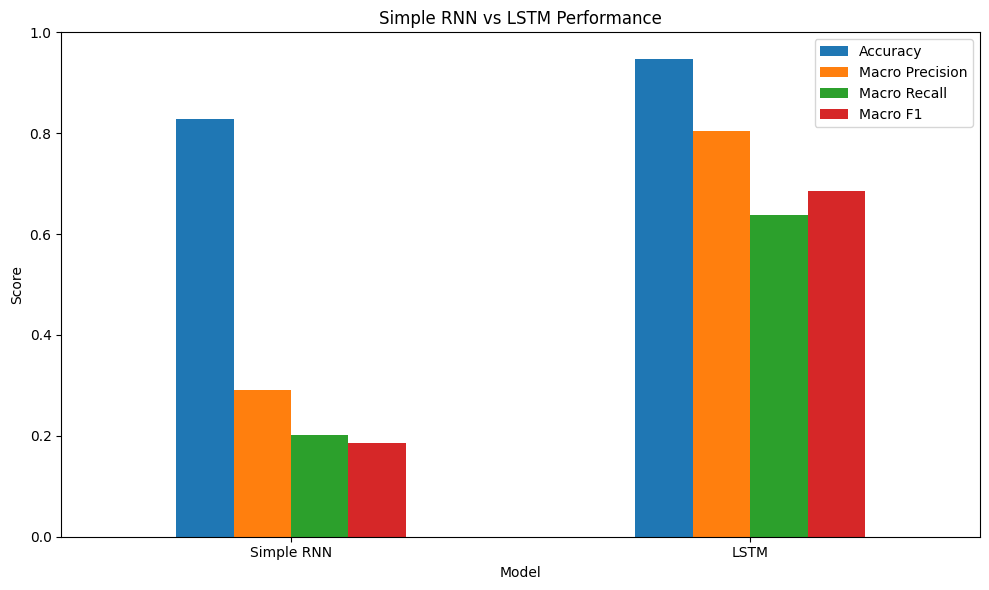

In [26]:
comparison_plot = comparison_df.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Simple RNN vs LSTM Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

## Why Did LSTM Perform Better?

The ECG heartbeat is sequential data, where the order and temporal relationships between measurements are important.

The Simple RNN processes the sequence using a hidden state, but it can struggle to preserve useful information across many time steps because of the vanishing-gradient problem.

The LSTM introduces gated memory mechanisms that control which information should be retained, forgotten, and passed forward.

In this experiment, the LSTM achieved substantially better performance than the Simple RNN:

- Simple RNN Macro F1: 18.49%
- LSTM Macro F1: 68.47%
- Simple RNN Accuracy: 82.80%
- LSTM Accuracy: 94.79%

The large improvement in macro-averaged metrics indicates that the LSTM was better able to recognize minority heartbeat categories instead of mainly predicting the majority Normal class.

Therefore, the results demonstrate the advantage of gated recurrent architectures for learning temporal patterns in ECG signals.

# Final Summary

In this experiment, ECG heartbeat signals were treated as sequential time-series data, where the order of signal measurements is important for classification.

The dataset contains five heartbeat categories: Normal, Supraventricular, Ventricular, Fusion, and Unknown. Due to the strong class imbalance in the dataset, model performance was evaluated using accuracy together with macro-averaged precision, recall, and F1-score.

Two sequential deep learning architectures were implemented and compared:

- Simple Recurrent Neural Network (RNN)
- Long Short-Term Memory (LSTM)

The Simple RNN achieved an accuracy of 82.80% but obtained a low macro F1-score of 18.49%. Its performance was strongly affected by the majority Normal class, resulting in poor recognition of minority heartbeat categories.

The LSTM achieved a substantially better accuracy of 94.79% and a macro F1-score of 68.47%. It also demonstrated considerably better performance across the minority classes.

Overall, the experiment demonstrates the importance of using sequence-aware architectures for ECG signal classification and highlights the advantage of LSTM's gated memory mechanism over a plain RNN.

# Conclusion

This experiment demonstrated how recurrent architectures can be applied to sequential ECG heartbeat classification.

The comparison between the Simple RNN and LSTM showed a clear performance advantage for the LSTM. While the Simple RNN achieved 82.80% accuracy, its macro F1-score was only 18.49%, indicating that it struggled to identify minority heartbeat categories.

In contrast, the LSTM achieved 94.79% accuracy with a macro F1-score of 68.47%. The improvement in macro-averaged performance indicates that the LSTM was better able to learn useful temporal patterns and recognize different heartbeat categories.

This result supports the use of LSTM networks for sequential ECG data, where information from different time steps can contribute to the classification decision.

The experiment also demonstrated why model evaluation should consider class imbalance and why metrics such as macro precision, macro recall, macro F1-score, and confusion matrices are important alongside accuracy.

Therefore, the main takeaway from Day 3 is that sequence-aware architectures are essential when the order of observations carries meaningful information, and LSTM's gated memory provides a practical solution to the limitations of plain RNNs.